In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = [
    # N = 128
    {"N": 128, "S": 4,  "Algorithm": "CPU",             "Time_ms": 1.1257,   "GFLOPS": 3.72595,   "Correct": "-"},
    {"N": 128, "S": 4,  "Algorithm": "GPU naive",       "Time_ms": 83.2233,  "GFLOPS": 0.0503982, "Correct": "YES"},
    {"N": 128, "S": 4,  "Algorithm": "GPU row cache",   "Time_ms": 0.7771,   "GFLOPS": 5.39738,   "Correct": "YES"},
    {"N": 128, "S": 4,  "Algorithm": "GPU col cache",   "Time_ms": 0.7946,   "GFLOPS": 5.27851,   "Correct": "YES"},
    {"N": 128, "S": 4,  "Algorithm": "GPU tiled",       "Time_ms": 0.8279,   "GFLOPS": 5.0662,    "Correct": "YES"},

    {"N": 128, "S": 8,  "Algorithm": "CPU",             "Time_ms": 1.1325,   "GFLOPS": 3.70358,   "Correct": "-"},
    {"N": 128, "S": 8,  "Algorithm": "GPU naive",       "Time_ms": 0.7925,   "GFLOPS": 5.2925,    "Correct": "YES"},
    {"N": 128, "S": 8,  "Algorithm": "GPU row cache",   "Time_ms": 0.6425,   "GFLOPS": 6.5281,    "Correct": "YES"},
    {"N": 128, "S": 8,  "Algorithm": "GPU col cache",   "Time_ms": 0.6537,   "GFLOPS": 6.41625,   "Correct": "YES"},
    {"N": 128, "S": 8,  "Algorithm": "GPU tiled",       "Time_ms": 0.5942,   "GFLOPS": 7.05874,   "Correct": "YES"},

    {"N": 128, "S": 16, "Algorithm": "CPU",             "Time_ms": 1.1474,   "GFLOPS": 3.65549,   "Correct": "-"},
    {"N": 128, "S": 16, "Algorithm": "GPU naive",       "Time_ms": 0.8204,   "GFLOPS": 5.11251,   "Correct": "YES"},
    {"N": 128, "S": 16, "Algorithm": "GPU row cache",   "Time_ms": 0.7235,   "GFLOPS": 5.79724,   "Correct": "YES"},
    {"N": 128, "S": 16, "Algorithm": "GPU col cache",   "Time_ms": 0.7358,   "GFLOPS": 5.70033,   "Correct": "YES"},
    {"N": 128, "S": 16, "Algorithm": "GPU tiled",       "Time_ms": 0.6790,   "GFLOPS": 6.17718,   "Correct": "YES"},

    {"N": 128, "S": 32, "Algorithm": "CPU",             "Time_ms": 1.1457,   "GFLOPS": 3.66091,   "Correct": "-"},
    {"N": 128, "S": 32, "Algorithm": "GPU naive",       "Time_ms": 1.0403,   "GFLOPS": 4.03182,   "Correct": "YES"},
    {"N": 128, "S": 32, "Algorithm": "GPU row cache",   "Time_ms": 0.6824,   "GFLOPS": 6.1464,    "Correct": "YES"},
    {"N": 128, "S": 32, "Algorithm": "GPU col cache",   "Time_ms": 0.6546,   "GFLOPS": 6.40743,   "Correct": "YES"},
    {"N": 128, "S": 32, "Algorithm": "GPU tiled",       "Time_ms": 1.3301,   "GFLOPS": 3.15337,   "Correct": "YES"},

    # N = 256
    {"N": 256, "S": 4,  "Algorithm": "CPU",             "Time_ms": 8.6122,   "GFLOPS": 3.89615,   "Correct": "-"},
    {"N": 256, "S": 4,  "Algorithm": "GPU naive",       "Time_ms": 1.7330,   "GFLOPS": 19.362,    "Correct": "YES"},
    {"N": 256, "S": 4,  "Algorithm": "GPU row cache",   "Time_ms": 1.9998,   "GFLOPS": 16.7789,   "Correct": "YES"},
    {"N": 256, "S": 4,  "Algorithm": "GPU col cache",   "Time_ms": 4.0663,   "GFLOPS": 8.25183,   "Correct": "YES"},
    {"N": 256, "S": 4,  "Algorithm": "GPU tiled",       "Time_ms": 1.7295,   "GFLOPS": 19.4012,   "Correct": "YES"},

    {"N": 256, "S": 8,  "Algorithm": "CPU",             "Time_ms": 8.5392,   "GFLOPS": 3.92946,   "Correct": "-"},
    {"N": 256, "S": 8,  "Algorithm": "GPU naive",       "Time_ms": 1.9395,   "GFLOPS": 17.3006,   "Correct": "YES"},
    {"N": 256, "S": 8,  "Algorithm": "GPU row cache",   "Time_ms": 1.9946,   "GFLOPS": 16.8226,   "Correct": "YES"},
    {"N": 256, "S": 8,  "Algorithm": "GPU col cache",   "Time_ms": 2.3059,   "GFLOPS": 14.5516,   "Correct": "YES"},
    {"N": 256, "S": 8,  "Algorithm": "GPU tiled",       "Time_ms": 1.7335,   "GFLOPS": 19.3565,   "Correct": "YES"},

    {"N": 256, "S": 16, "Algorithm": "CPU",             "Time_ms": 8.7007,   "GFLOPS": 3.85652,   "Correct": "-"},
    {"N": 256, "S": 16, "Algorithm": "GPU naive",       "Time_ms": 1.7469,   "GFLOPS": 19.208,    "Correct": "YES"},
    {"N": 256, "S": 16, "Algorithm": "GPU row cache",   "Time_ms": 1.5913,   "GFLOPS": 21.0862,   "Correct": "YES"},
    {"N": 256, "S": 16, "Algorithm": "GPU col cache",   "Time_ms": 1.9111,   "GFLOPS": 17.5577,   "Correct": "YES"},
    {"N": 256, "S": 16, "Algorithm": "GPU tiled",       "Time_ms": 1.6158,   "GFLOPS": 20.7665,   "Correct": "YES"},

    {"N": 256, "S": 32, "Algorithm": "CPU",             "Time_ms": 8.6702,   "GFLOPS": 3.87009,   "Correct": "-"},
    {"N": 256, "S": 32, "Algorithm": "GPU naive",       "Time_ms": 2.0466,   "GFLOPS": 16.3952,   "Correct": "YES"},
    {"N": 256, "S": 32, "Algorithm": "GPU row cache",   "Time_ms": 1.5493,   "GFLOPS": 21.6578,   "Correct": "YES"},
    {"N": 256, "S": 32, "Algorithm": "GPU col cache",   "Time_ms": 1.7882,   "GFLOPS": 18.7644,   "Correct": "YES"},
    {"N": 256, "S": 32, "Algorithm": "GPU tiled",       "Time_ms": 1.5061,   "GFLOPS": 22.279,    "Correct": "YES"},

    # N = 512
    {"N": 512, "S": 4,  "Algorithm": "CPU",             "Time_ms": 104.414,  "GFLOPS": 2.57087,   "Correct": "-"},
    {"N": 512, "S": 4,  "Algorithm": "GPU naive",       "Time_ms": 6.0135,   "GFLOPS": 44.6388,   "Correct": "YES"},
    {"N": 512, "S": 4,  "Algorithm": "GPU row cache",   "Time_ms": 9.6733,   "GFLOPS": 27.7501,   "Correct": "YES"},
    {"N": 512, "S": 4,  "Algorithm": "GPU col cache",   "Time_ms": 10.6547,  "GFLOPS": 25.1941,   "Correct": "YES"},
    {"N": 512, "S": 4,  "Algorithm": "GPU tiled",       "Time_ms": 6.2680,   "GFLOPS": 42.8263,   "Correct": "YES"},

    {"N": 512, "S": 8,  "Algorithm": "CPU",             "Time_ms": 104.388,  "GFLOPS": 2.57153,   "Correct": "-"},
    {"N": 512, "S": 8,  "Algorithm": "GPU naive",       "Time_ms": 5.4062,   "GFLOPS": 49.6533,   "Correct": "YES"},
    {"N": 512, "S": 8,  "Algorithm": "GPU row cache",   "Time_ms": 6.3043,   "GFLOPS": 42.5797,   "Correct": "YES"},
    {"N": 512, "S": 8,  "Algorithm": "GPU col cache",   "Time_ms": 8.0834,   "GFLOPS": 33.2082,   "Correct": "YES"},
    {"N": 512, "S": 8,  "Algorithm": "GPU tiled",       "Time_ms": 5.3056,   "GFLOPS": 50.5947,   "Correct": "YES"},

    {"N": 512, "S": 16, "Algorithm": "CPU",             "Time_ms": 105.465,  "GFLOPS": 2.54527,   "Correct": "-"},
    {"N": 512, "S": 16, "Algorithm": "GPU naive",       "Time_ms": 5.4897,   "GFLOPS": 48.898,    "Correct": "YES"},
    {"N": 512, "S": 16, "Algorithm": "GPU row cache",   "Time_ms": 5.9882,   "GFLOPS": 44.8274,   "Correct": "YES"},
    {"N": 512, "S": 16, "Algorithm": "GPU col cache",   "Time_ms": 8.1115,   "GFLOPS": 33.0932,   "Correct": "YES"},
    {"N": 512, "S": 16, "Algorithm": "GPU tiled",       "Time_ms": 5.3319,   "GFLOPS": 50.3452,   "Correct": "YES"},

    {"N": 512, "S": 32, "Algorithm": "CPU",             "Time_ms": 104.956,  "GFLOPS": 2.55761,   "Correct": "-"},
    {"N": 512, "S": 32, "Algorithm": "GPU naive",       "Time_ms": 5.5241,   "GFLOPS": 48.5935,   "Correct": "YES"},
    {"N": 512, "S": 32, "Algorithm": "GPU row cache",   "Time_ms": 5.3329,   "GFLOPS": 50.3357,   "Correct": "YES"},
    {"N": 512, "S": 32, "Algorithm": "GPU col cache",   "Time_ms": 7.8031,   "GFLOPS": 34.4011,   "Correct": "YES"},
    {"N": 512, "S": 32, "Algorithm": "GPU tiled",       "Time_ms": 5.7664,   "GFLOPS": 46.5517,   "Correct": "YES"},

    # N = 1024
    {"N": 1024, "S": 4,  "Algorithm": "CPU",             "Time_ms": 2420.75, "GFLOPS": 0.887116,  "Correct": "-"},
    {"N": 1024, "S": 4,  "Algorithm": "GPU naive",       "Time_ms": 26.3578, "GFLOPS": 81.4743,   "Correct": "YES"},
    {"N": 1024, "S": 4,  "Algorithm": "GPU row cache",   "Time_ms": 57.7923, "GFLOPS": 37.1586,   "Correct": "YES"},
    {"N": 1024, "S": 4,  "Algorithm": "GPU col cache",   "Time_ms": 63.7831, "GFLOPS": 33.6685,   "Correct": "YES"},
    {"N": 1024, "S": 4,  "Algorithm": "GPU tiled",       "Time_ms": 25.7482, "GFLOPS": 83.4033,   "Correct": "YES"},

    {"N": 1024, "S": 8,  "Algorithm": "CPU",             "Time_ms": 2136.22, "GFLOPS": 1.00527,   "Correct": "-"},
    {"N": 1024, "S": 8,  "Algorithm": "GPU naive",       "Time_ms": 20.7616, "GFLOPS": 103.435,   "Correct": "YES"},
    {"N": 1024, "S": 8,  "Algorithm": "GPU row cache",   "Time_ms": 30.6927, "GFLOPS": 69.9672,   "Correct": "YES"},
    {"N": 1024, "S": 8,  "Algorithm": "GPU col cache",   "Time_ms": 44.5987, "GFLOPS": 48.1513,   "Correct": "YES"},
    {"N": 1024, "S": 8,  "Algorithm": "GPU tiled",       "Time_ms": 21.4112, "GFLOPS": 100.297,   "Correct": "YES"},

    {"N": 1024, "S": 16, "Algorithm": "CPU",             "Time_ms": 2290.07, "GFLOPS": 0.937735,  "Correct": "-"},
    {"N": 1024, "S": 16, "Algorithm": "GPU naive",       "Time_ms": 24.0793, "GFLOPS": 89.1838,   "Correct": "YES"},
    {"N": 1024, "S": 16, "Algorithm": "GPU row cache",   "Time_ms": 27.8241, "GFLOPS": 77.1807,   "Correct": "YES"},
    {"N": 1024, "S": 16, "Algorithm": "GPU col cache",   "Time_ms": 77.5038, "GFLOPS": 27.7081,   "Correct": "YES"},
    {"N": 1024, "S": 16, "Algorithm": "GPU tiled",       "Time_ms": 25.6124, "GFLOPS": 83.8455,   "Correct": "YES"},

    {"N": 1024, "S": 32, "Algorithm": "CPU",             "Time_ms": 2414.31, "GFLOPS": 0.889482,  "Correct": "-"},
    {"N": 1024, "S": 32, "Algorithm": "GPU naive",       "Time_ms": 60.0075, "GFLOPS": 35.7869,   "Correct": "YES"},
    {"N": 1024, "S": 32, "Algorithm": "GPU row cache",   "Time_ms": 51.8463, "GFLOPS": 41.4202,   "Correct": "YES"},
    {"N": 1024, "S": 32, "Algorithm": "GPU col cache",   "Time_ms": 166.117, "GFLOPS": 12.9275,   "Correct": "YES"},
    {"N": 1024, "S": 32, "Algorithm": "GPU tiled",       "Time_ms": 20.2904, "GFLOPS": 105.837,   "Correct": "YES"},
]

In [3]:
df = pd.DataFrame(data)
df

,N,S,Algorithm,Time_ms,GFLOPS,Correct
0,128,4,CPU,1.1257,3.725950,-
1,128,4,GPU naive,83.2233,0.050398,YES
2,128,4,GPU row cache,0.7771,5.397380,YES
3,128,4,GPU col cache,0.7946,5.278510,YES
4,128,4,GPU tiled,0.8279,5.066200,YES
...,...,...,...,...,...,...
75,1024,32,CPU,2414.3100,0.889482,-
76,1024,32,GPU naive,60.0075,35.786900,YES
77,1024,32,GPU row cache,51.8463,41.420200,YES
78,1024,32,GPU col cache,166.1170,12.927500,YES


In [4]:
gpu_df = df[df["Algorithm"] != "CPU"].copy()
cpu_df = df[df["Algorithm"] == "CPU"].copy()

gpu_df

,N,S,Algorithm,Time_ms,GFLOPS,Correct
1,128,4,GPU naive,83.2233,0.050398,YES
2,128,4,GPU row cache,0.7771,5.397380,YES
3,128,4,GPU col cache,0.7946,5.278510,YES
4,128,4,GPU tiled,0.8279,5.066200,YES
6,128,8,GPU naive,0.7925,5.292500,YES
...,...,...,...,...,...,...
74,1024,16,GPU tiled,25.6124,83.845500,YES
76,1024,32,GPU naive,60.0075,35.786900,YES
77,1024,32,GPU row cache,51.8463,41.420200,YES
78,1024,32,GPU col cache,166.1170,12.927500,YES


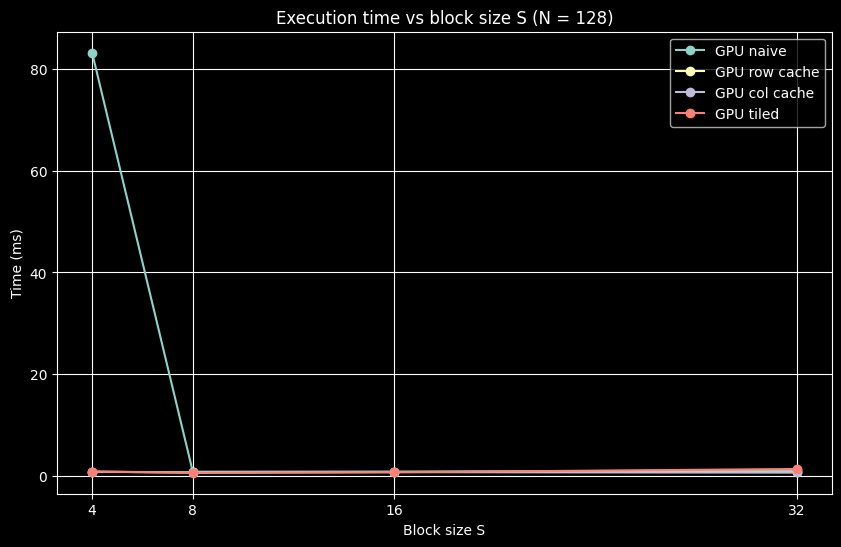

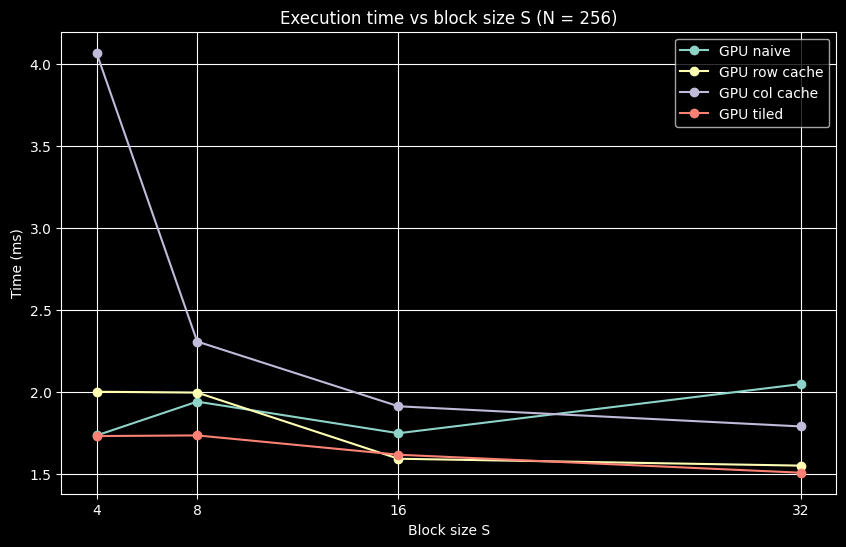

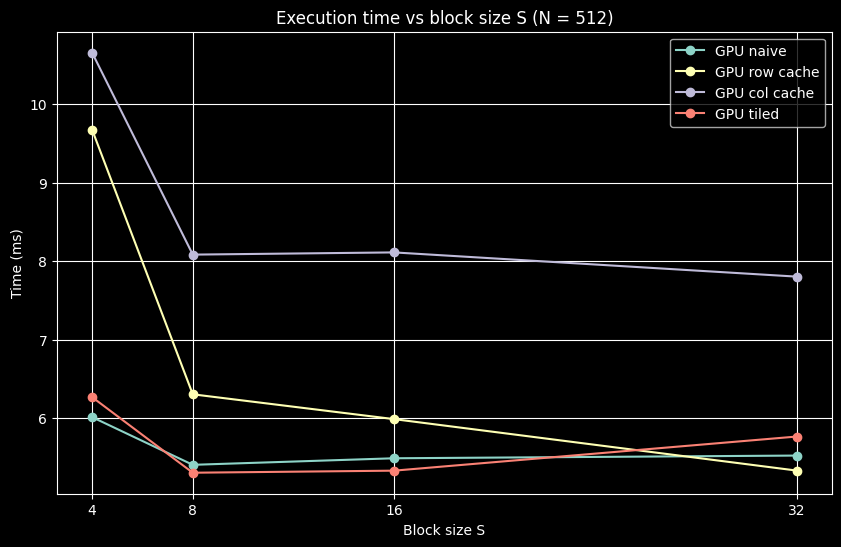

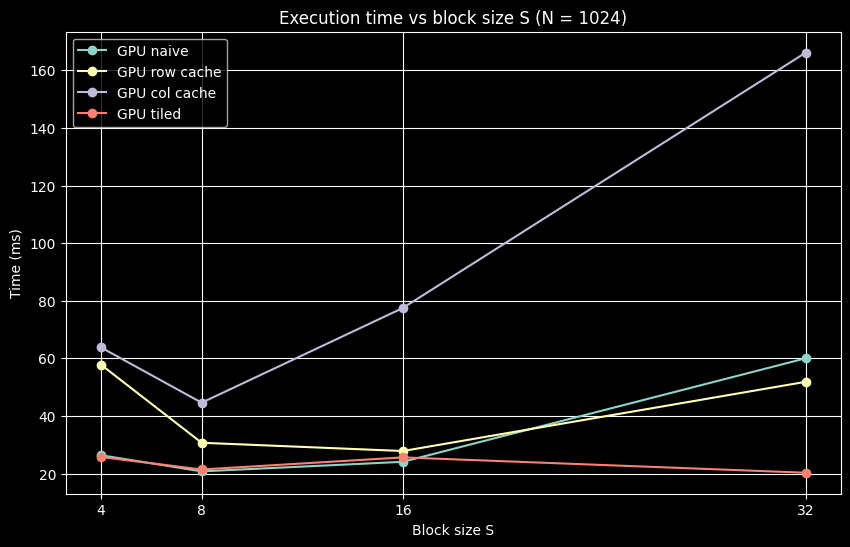

In [5]:
N_values = sorted(gpu_df["N"].unique())
algorithms = gpu_df["Algorithm"].unique()

for N in N_values:
    plt.figure(figsize=(10, 6))

    subset = gpu_df[gpu_df["N"] == N]

    for algo in algorithms:
        part = subset[subset["Algorithm"] == algo].sort_values("S")
        plt.plot(part["S"], part["Time_ms"], marker="o", label=algo)

    plt.title(f"Execution time vs block size S (N = {N})")
    plt.xlabel("Block size S")
    plt.ylabel("Time (ms)")
    plt.xticks(sorted(subset["S"].unique()))
    plt.grid(True)
    plt.legend()
    plt.show()

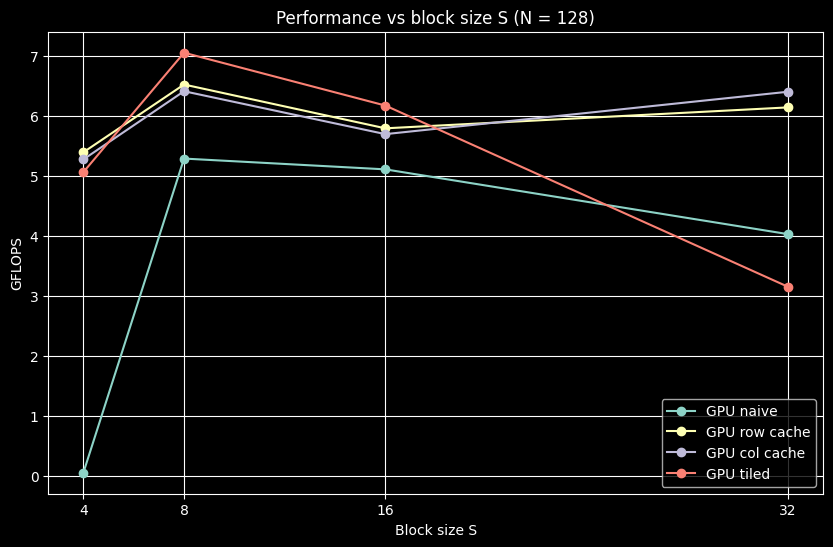

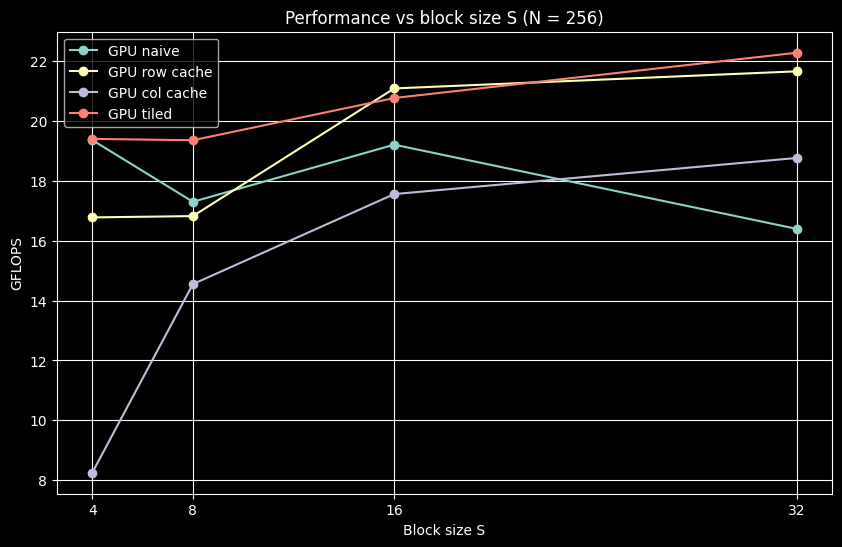

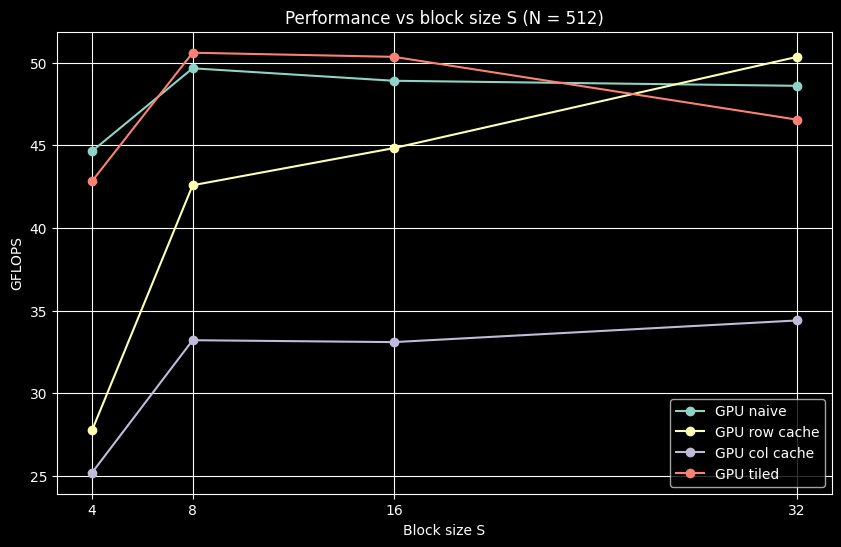

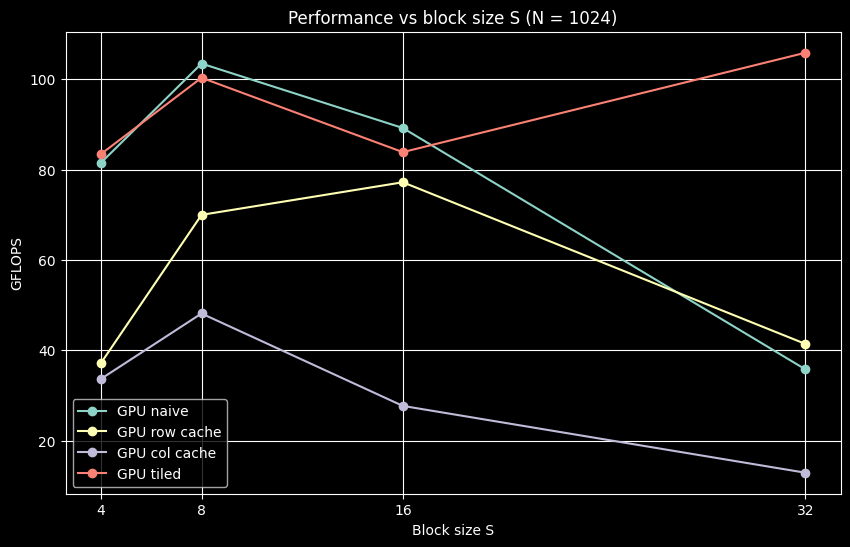

In [6]:
for N in N_values:
    plt.figure(figsize=(10, 6))

    subset = gpu_df[gpu_df["N"] == N]

    for algo in algorithms:
        part = subset[subset["Algorithm"] == algo].sort_values("S")
        plt.plot(part["S"], part["GFLOPS"], marker="o", label=algo)

    plt.title(f"Performance vs block size S (N = {N})")
    plt.xlabel("Block size S")
    plt.ylabel("GFLOPS")
    plt.xticks(sorted(subset["S"].unique()))
    plt.grid(True)
    plt.legend()
    plt.show()

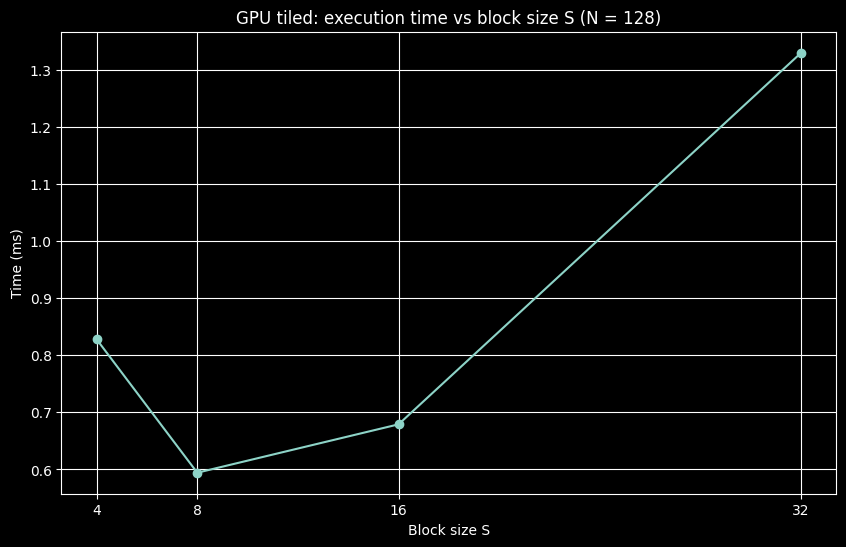

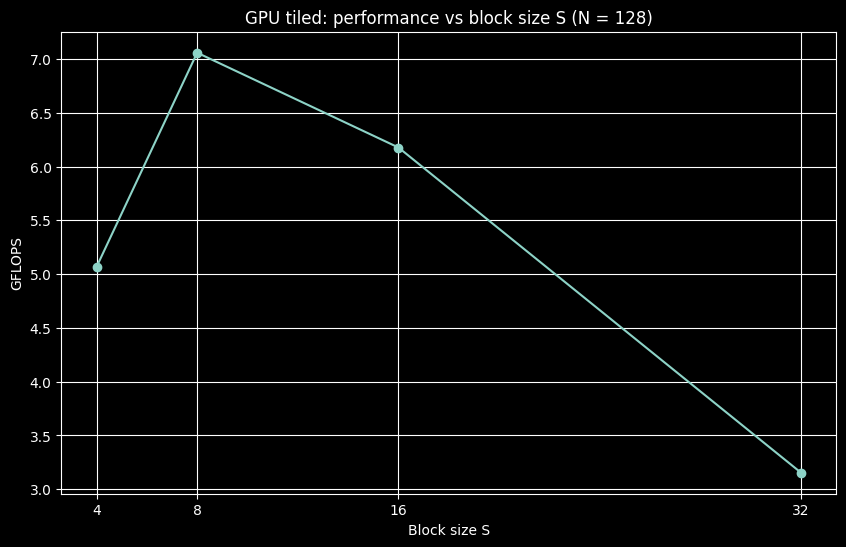

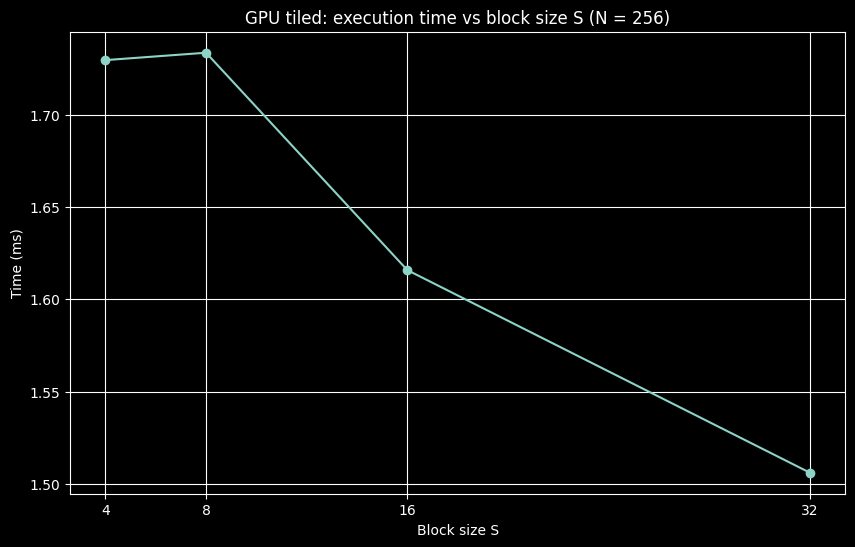

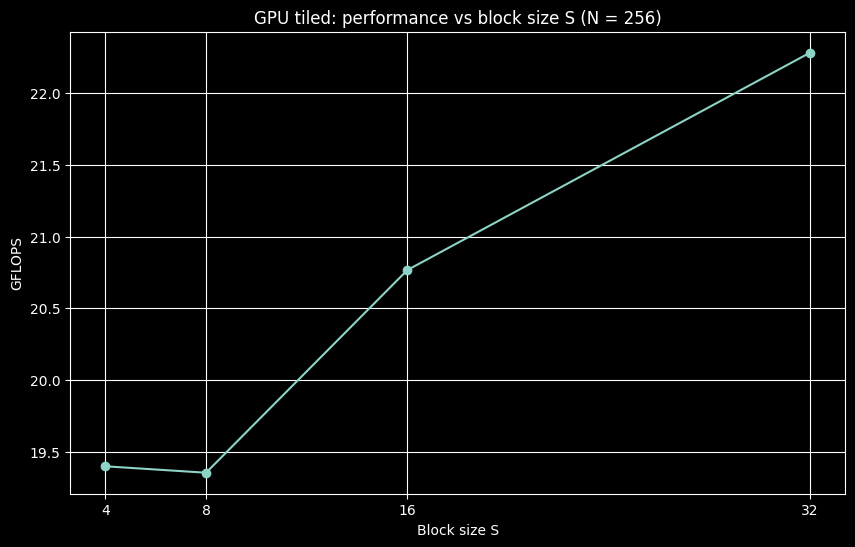

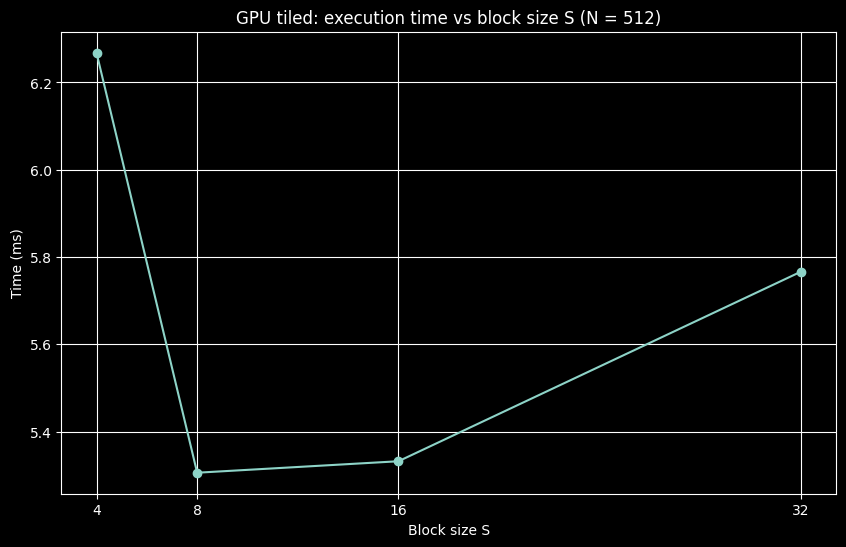

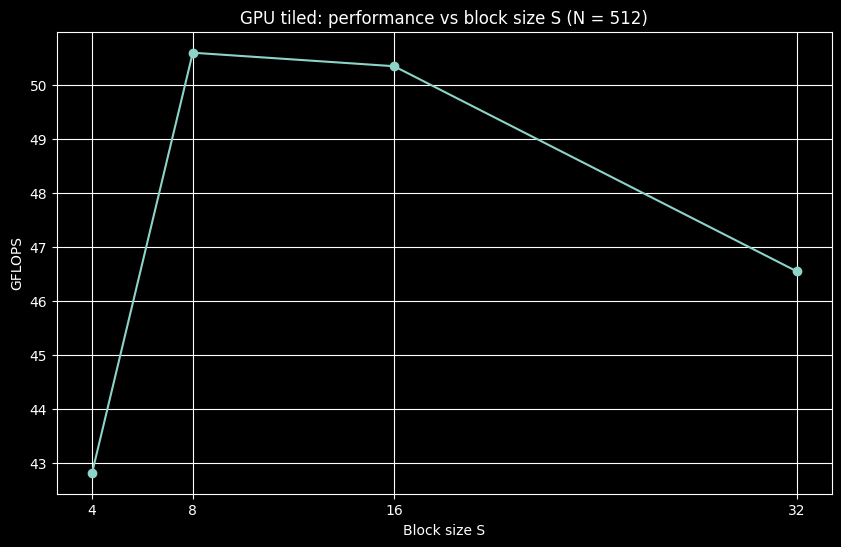

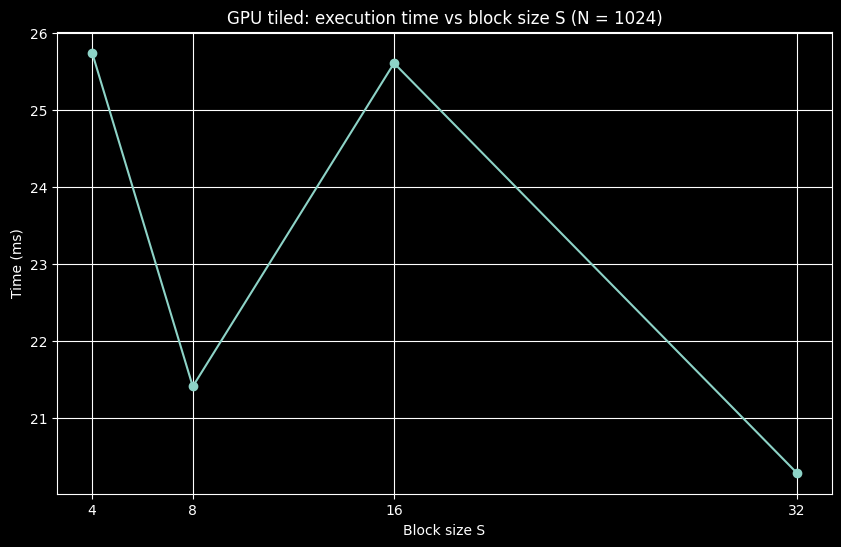

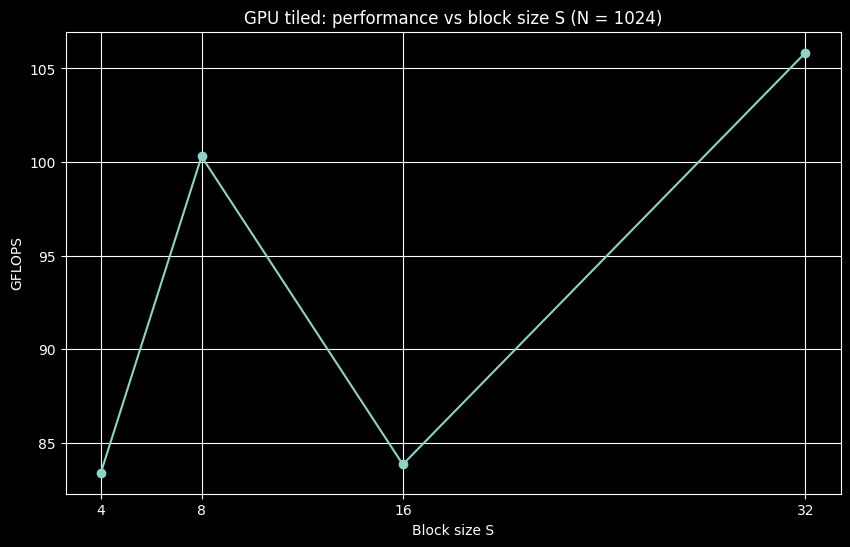

In [7]:
tiled_df = gpu_df[gpu_df["Algorithm"] == "GPU tiled"].copy()

for N in sorted(tiled_df["N"].unique()):
    plt.figure(figsize=(10, 6))

    subset = tiled_df[tiled_df["N"] == N].sort_values("S")

    plt.plot(subset["S"], subset["Time_ms"], marker="o")
    plt.title(f"GPU tiled: execution time vs block size S (N = {N})")
    plt.xlabel("Block size S")
    plt.ylabel("Time (ms)")
    plt.xticks(sorted(subset["S"].unique()))
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 6))
    plt.plot(subset["S"], subset["GFLOPS"], marker="o")
    plt.title(f"GPU tiled: performance vs block size S (N = {N})")
    plt.xlabel("Block size S")
    plt.ylabel("GFLOPS")
    plt.xticks(sorted(subset["S"].unique()))
    plt.grid(True)
    plt.show()